In [27]:
import pandas as pd
import numpy as np

team_df = pd.read_csv("Team_data_transformed2.csv").iloc[:, 1:]

# Fill missing slope values – here we use the median rather than zero
team_df["XG_slope"] = team_df["XG_slope"].fillna(team_df["XG_slope"].median())
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(team_df["XGC_slope"].median())

# Create opponent dataframe with selected columns
opponent_df = team_df[["code", "XGA", "XGCA", "XGH", "XGCH", "kickoff_time", "XG_slope", "XGC_slope","XG_avg","XGC_avg"]].copy()

# Merge team and opponent data on opponent code and kickoff time
# Suffixes indicate which data comes from team_df and which from opponent_df
pred_df = pd.merge(team_df, opponent_df, 
                   left_on=['opponent', 'kickoff_time'], 
                   right_on=['code', 'kickoff_time'], 
                   how='left', suffixes=('_team', '_opp'))

# --- 2. Construct Prediction Dataset with Clear Feature Assignment ---
print(pred_df)
# Start with key columns from the team data
Model_pred = pred_df[["name", "kickoff_time", "was_home", "XG", "XGC"]].copy()

# Use vectorized operations to assign attacking and defensive stats.
# The assumption is:
# - For a home game: use home expected stats from opponent data (XGH and XGCH)
# - For an away game: use away expected stats (XGA and XGCA)
Model_pred["Own_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGH_team"], pred_df["XGA_team"])
Model_pred["Own_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCH_team"], pred_df["XGCA_team"])
Model_pred["Opposition_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGA_opp"], pred_df["XGH_opp"])
Model_pred["Opposition_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCA_opp"], pred_df["XGCH_opp"])
Model_pred["Opposition_XG_avg"] = pred_df["XG_avg_opp"]
Model_pred["Opposition_XGC_avg"] = pred_df["XGC_avg_opp"]
Model_pred["Own_XG_avg"] = pred_df["XG_avg_team"]
Model_pred["Own_XGC_avg"] = pred_df["XGC_avg_team"]


# Include slope features from each source
Model_pred["Own_XG_slope"] = pred_df["XG_slope_team"]
Model_pred["Own_XGC_slope"] = pred_df["XGC_slope_team"]
Model_pred["Opponent_XG_slope"] = pred_df["XG_slope_opp"]
Model_pred["Opponent_XGC_slope"] = pred_df["XGC_slope_opp"]
Model_pred.to_csv("Team_data_preds.csv")
"""team_df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
team_df["XG_slope"] = team_df["XG_slope"].fillna(0)
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(0)
opponent_df=team_df[["code", "XGA", "XGCA", "XGH", "XGCH","kickoff_time","XG_slope","XGC_slope"]]

pred_df = pd.merge(team_df, opponent_df, left_on=['opponent', 'kickoff_time'], right_on=['code', 'kickoff_time'], how='left')
print(pred_df)

Model_pred=pred_df[["name","kickoff_time","was_home","XG","XGC"]]
Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
Model_pred["Own_XGC"]=pred_df.apply(lambda row: row[14] if row[6] else row[12], axis=1)
Model_pred["Opposition_XG"]=pred_df.apply(lambda row: row[16] if row[6] else row[18], axis=1)
Model_pred["Opposition_XGC"]=pred_df.apply(lambda row: row[17] if row[6] else row[19], axis=1)

Model_pred["Own_XG_slope"]=pred_df["XG_slope_x"].values
Model_pred["Own_XGC_slope"]=pred_df["XGC_slope_x"].values
Model_pred["Opponent_XG_slope"]=pred_df["XG_slope_y"].values
Model_pred["Opponent_XGC_slope"]=pred_df["XGC_slope_y"].values
Model_pred.to_csv("Team_data_preds.csv")"""
import numpy as np
import xgboost as xgb
from datetime import datetime

Model_pred['kickoff_time'] = pd.to_datetime(Model_pred['kickoff_time'])

# Get current year and month
current_year = datetime.today().year
current_month = datetime.today().month

# Filter for current month
test_df = Model_pred[(Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month)| 
               (Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month-1) ]
train_df = Model_pred[(Model_pred['kickoff_time'].dt.year < current_year) | 
                 ((Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month < current_month-1))]

import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg']
#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC'] # Exclude target and date
target = 'XG'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Initialize and Train XGBoost Model
model_xg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=80, learning_rate=0.1, max_depth=4,min_child_weight=6)
model_xg.fit(X_train, y_train)

# Make Predictions
y_pred = model_xg.predict(X_test)

# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")


import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Opposition_XG_avg','Own_XGC_avg']
#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC']# Exclude target and date
target = 'XGC'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Initialize and Train XGBoost Model
model_xgc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=80, learning_rate=0.1, max_depth=4,min_child_weight=6)
model_xgc.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgc.predict(X_test)

# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")

fixture_data=pd.read_csv("Raw_Data_24/Fantasy_season_2024_Fixtures.csv")[["event","team_a","team_h","finished"]]
team_code_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")[["name","code","id"]]
team_data=pd.read_csv("Team_data_newest2.csv")[["code","XGA","XGCA","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg"]]
#fixture_data=fixture_data[fixture_data["finished"]==False]
fixture_data=fixture_data[fixture_data["event"]>32]
min_event=fixture_data["event"].min()
horizon=9
min_event_list=[]
for i in range(horizon):
    min_event_list.append(min_event+i)

fixture_data = fixture_data[fixture_data["event"].isin(min_event_list)]


df_merged = fixture_data.merge(team_code_data, left_on='team_a', right_on='id', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_code_data, left_on='team_h', right_on='id', how='left')  # Left join to keep all rows from df2
predict_data=df_merged[["event"]]
predict_data["team_a"]=df_merged["code_x"].values
predict_data["team_h"]=df_merged["code_y"].values
predict_data["team_a_name"]=df_merged["name_x"].values
predict_data["team_h_name"]=df_merged["name_y"].values
df_merged = predict_data.merge(team_data[["code","XGA","XGCA","XG_slope","XGC_slope","XG_avg","XGC_avg"]], left_on='team_a', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_data[["code","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg"]], left_on='team_h', right_on='code', how='left')  # Left join to keep all rows from df2


features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg']

new_input_XG = pd.DataFrame()
new_input_XG["Own_XG"]=df_merged["XGH"]
new_input_XG["Opposition_XGC"]=df_merged["XGCA"]
new_input_XG["Own_XG_slope"]=df_merged["XG_slope_y"]
new_input_XG["Opponent_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XG["Own_XG_avg"]=df_merged["XG_avg_y"]
new_input_XG["Opposition_XGC_avg"]=df_merged["XGC_avg_x"]



new_input_XG2 = pd.DataFrame()
new_input_XG2["Own_XG"]=df_merged["XGA"]
new_input_XG2["Opposition_XGC"]=df_merged["XGCH"]
new_input_XG2["Own_XG_slope"]=df_merged["XG_slope_x"]
new_input_XG2["Opponent_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XG2["Own_XG_avg"]=df_merged["XG_avg_x"]
new_input_XG2["Opposition_XGC_avg"]=df_merged["XGC_avg_y"]
"""new_input_XG2["Name"]=df_merged["team_h_name"]    
new_input_XG2["Opponent_Name"]=df_merged["team_a_name"]"""    
new_input_XG2.to_csv("teams_preds_test.csv")


xg = model_xg.predict(new_input_XG)
xg2 = model_xg.predict(new_input_XG2)


features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Own_XGC_avg','Opposition_XG_avg']
new_input_XGC = pd.DataFrame()
new_input_XGC["Own_XGC"]=df_merged["XGCH"]
new_input_XGC["Opposition_XG"]=df_merged["XGA"]
new_input_XGC["Own_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XGC["Opponent_XG_slope"]=df_merged["XG_slope_x"]
new_input_XGC["Opposition_XG_avg"]=df_merged["XGC_avg_x"]
new_input_XGC["Own_XGC_avg"]=df_merged["XG_avg_y"]


new_input_XGC2 = pd.DataFrame()
new_input_XGC2["Own_XGC"]=df_merged["XGCA"]
new_input_XGC2["Opposition_XG"]=df_merged["XGH"]
new_input_XGC2["Own_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XGC2["Opponent_XG_slope"]=df_merged["XG_slope_y"]
new_input_XGC2["Opposition_XG_avg"]=df_merged["XGC_avg_y"]
new_input_XGC2["Own_XGC_avg"]=df_merged["XG_avg_x"]


xgc = model_xgc.predict(new_input_XGC)
xgc2 = model_xgc.predict(new_input_XGC2)


result_df=pd.DataFrame()
result_df["GW"]=df_merged["event"]
result_df["pred"]=df_merged["event"]-min_event+1
result_df["home_team"]=df_merged["team_h_name"]
result_df["away_team"]=df_merged["team_a_name"]
result_df["home_code"]=df_merged["team_h"]
result_df["away_code"]=df_merged["team_a"]
result_df["home_goals"]=(xg+xgc2)/2
result_df["away_goals"]=(xgc+xg2)/2
result_df.to_csv("Team_prediction_visual.csv")

home_df=result_df[["GW", "pred"]]
home_df["team_name"]=result_df["home_team"]
home_df["team_code"]=result_df["home_code"]
home_df["XG"]=result_df["home_goals"]
home_df["XGC"]=result_df["away_goals"]

away_df=result_df[["GW", "pred"]]
away_df["team_name"]=result_df["away_team"]
away_df["team_code"]=result_df["away_code"]
away_df["XG"]=result_df["away_goals"]
away_df["XGC"]=result_df["home_goals"]

ALL_pred=pd.concat([home_df, away_df], axis=0, ignore_index=True)
ALL_pred.to_csv("Team_prediction.csv")


#0.62
#0.65

             name  code_team  id          kickoff_time     XG    XGC  \
0     Southampton         20  17  2022-08-06T14:00:00Z  1.000  4.000   
1     Southampton         20  17  2022-08-13T14:00:00Z  2.000  2.000   
2     Southampton         20  17  2022-08-20T14:00:00Z  2.000  1.000   
3     Southampton         20  17  2022-08-27T11:30:00Z  0.000  1.000   
4     Southampton         20  17  2022-08-30T18:45:00Z  2.000  1.000   
...           ...        ...  ..                   ...    ...    ...   
2155      Ipswich         40  10  2025-03-08T15:00:00Z  0.900  2.130   
2156      Ipswich         40  10  2025-03-15T15:00:00Z  1.220  2.760   
2157      Ipswich         40  10  2025-04-02T18:45:00Z  1.585  1.435   
2158      Ipswich         40  10  2025-04-05T14:00:00Z  0.900  2.355   
2159      Ipswich         40  10  2025-04-13T13:00:00Z  1.540  2.135   

      was_home  opponent    XG_DEF    XG_MID  ...  XGC_slope_team  code_opp  \
0        False       6.0  2.000000  1.000000  ...       

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\3017471375.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_a"]=df_merged["code_x"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\3017471375.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_h"]=df_merged["code_y"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\3017471375.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

114
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge_Luiz Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Ethan_Nwaneri' 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice'
 'Bukayo_Saka' 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney'
 'Leandro_Trossard' 'Benjamin_White' 'Oleksandr_Zinchenko'
 'Raheem_Sterling' 'Riccardo_Calafiori' 'Myles_Lewis-Skelly'
 'Mikel_Merino' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego_Carlos Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Kosta_Nedeljković' 'Robin_Olsen' 'Pau_Torres'
 'Jacob_Ramsey' 'Morgan_Rogers' 'Youri_Tielemans' 'Ollie_Watkins'
 'Amadou_Onana' 'Jaden_Philogene' 'Lamare_Bogarde' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fábio_Ferreira Vieira
Gabriel_Fernando de Jesus
Gabriel_dos Santos Magalhães
Kai_Havertz0
Kai_Havertz1
Jurriën_Timber
Jorge_Luiz Frello Filho0
Jorge_Luiz Frello Filho1
Jakub_Kiwior
Gabriel_Martinelli Silva
Ethan_Nwaneri
Martin_Ødegaard
David_Raya Martin0
David_Raya Martin1
Declan_Rice0


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Declan_Rice1
Bukayo_Saka
William_Saliba
Thomas_Partey
Kieran_Tierney
Leandro_Trossard0
Leandro_Trossard1
Benjamin_White
Oleksandr_Zinchenko
Raheem_Sterling0
Raheem_Sterling1
Riccardo_Calafiori
Myles_Lewis-Skelly
Mikel_Merino
Leon_Bailey
Ross_Barkley0
Ross_Barkley1
Emiliano_Buendía Stati
Matty_Cash


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Joseph_Hodge
Adam_Forshaw
Tomas_Soucek
Wilfried_Zaha
Junior_Firpo Adames
Mohamed_Elyounoussi
Ibrahima_Diallo
Jesse_Lingard
Robin_Koch
Kelechi_Iheanacho
Manuel_Lanzini
Ayoze_Pérez
Marc_Albrighton
Adama_Traoré Diarra
Ruben_Loftus-Cheek
Illan_Meslier
David_De Gea Quintana
Cédric_Alves Soares
Patrick_Bamford
Neeskens_Kebano
Rúben_da Silva Neves
Mateo_Kovacic
Diego_Llorente
Kalidou_Koulibaly
Joseph_Gomez
Yerry_Mina
Pascal_Struijk
Theo_Walcott
Marc_Roca Junqué
Vladimir_Coufal
Rasmus_Kristensen
Jack_Colback
Romain_Perraud
João_Filipe Iria Santos Moutinho
Çaglar_Söyüncü
Joel_Robles
Renan_Augusto Lodi dos Santos
Denis_Zakaria
Duje_Caleta-Car
Wilfried_Gnonto
Diego_Da Silva Costa
Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

XG_Mean_difference


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

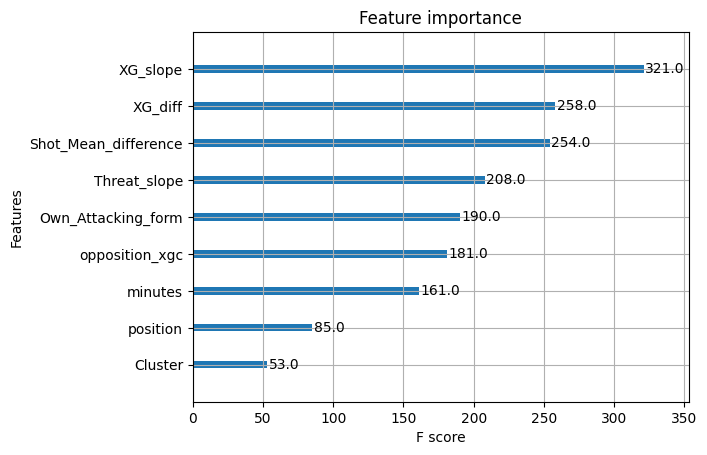

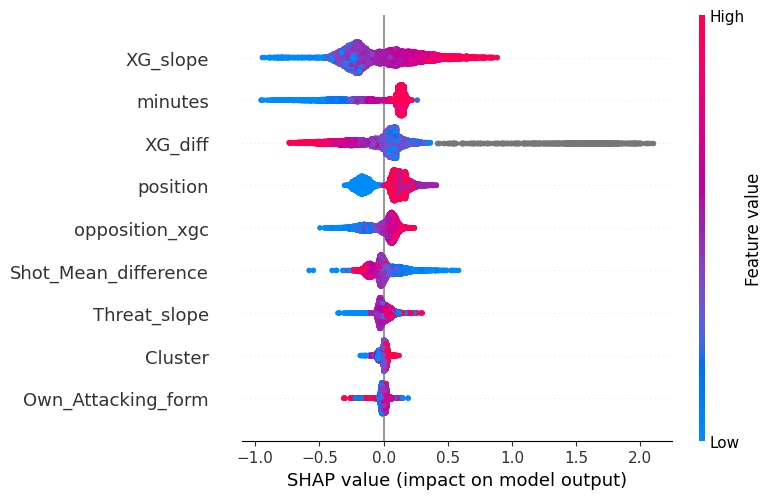

tensor(0.0865, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:441: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
[0.37848772 0.29255798 0.38034791 0.08874785 0.29540482 0.43855229]


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:547: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:494: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
[0.07882101 0.06199303 0.06764929 0.04878204 0.06268282 0.09059535]


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Hugo_Lloris
Frederico_Rodrigues de Paula Santos
Shandon_Baptiste
Maxwel_Cornet
Josh_Cullen
Joel_Matip
Davinson_Sánchez
Amari'i_Bell
Luke_Berry
Cheikhou_Kouyaté
Pierre-Emerick_Aubameyang
Seamus_Coleman
Anthony_Martial
Olu_Aina
Rodrigo_Hernandez
Fred_Onyedinma
Gustavo_Henrique Furtado Scarpa
David_Datro Fofana
Joe_Rothwell
Vini_de Souza Costa
Fabio_Henrique Tavares
Oliver_McBurnie
Ryan_Fredericks
Siriki_Dembélé
Jonjo_Shelvey
Thilo_Kehrer
Ameen_Al-Dakhil
Norberto_Murara Neto
Rhian_Brewster
Tom_Lockyer
Anis_Slimane
Jacob_Bruun Larsen
Alfie_Doughty
João_Cancelo
Mohamed_Elneny
Ivan_Perišić
Anel_Ahmedhodžić
Yasser_Larouci
Carlton_Morris
Cauley_Woodrow
Harry_Kane
Yegor_Yarmoliuk
Christian_Pulisic
Josh_Brownhill
César_Azpilicueta
Steve_Cook
Hjalmar_Ekdal
Thiago_Emiliano da Silva
Rob_Holding
Bertrand_Traoré
Serge_Aurier
Bénie_Traoré
Jordan_Beyer
Wes_Foderingham
Matt_Ritchie
Lyle_Foster
Nathan_Redmond
Michael_Olise
Scott_McKenna
Sasa_Kalajdzic
Matt_Turner
Mads_Juel Andersen
Dominic_Solanke
George

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

XA_Mean_difference


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

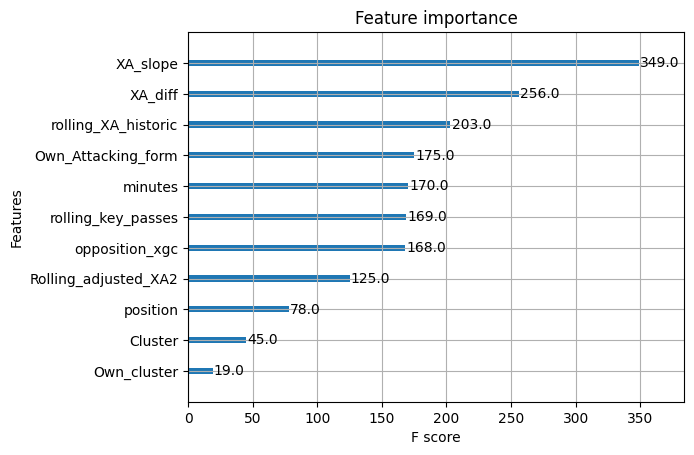

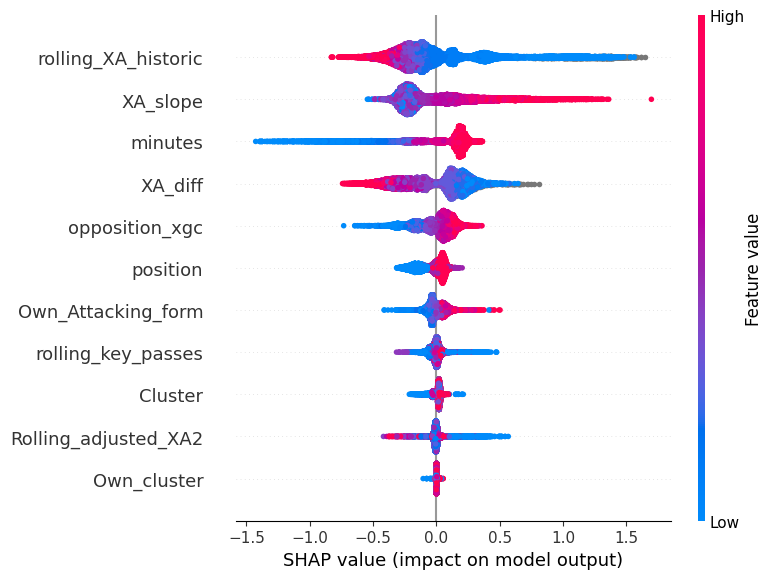

tensor(0.0513, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:441: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
[0.2037387  0.100975   0.1633692  0.05034542 0.10650476 0.23809004]


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:547: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:494: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
[0.0750649  0.06170782 0.07590856 0.03479098 0.06343962 0.08199209]


...

João_Filipe Iria Santos Moutinho
Çaglar_Söyüncü
Joel_Robles
Renan_Augusto Lodi dos Santos
Denis_Zakaria
Duje_Caleta-Car
Wilfried_Gnonto
Diego_Da Silva Costa
Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

expected_goals_conceded


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')


Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
Kristoffer_Ajer
Kristoffer_Ajer
Rayan_Aït-Nouri
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Benoît_Badiashile
Benoît_Badiashile
Trevoh_Chalobah0
Benoît_Badiashile
Lewis_Dunk
Benoît_Badiashile
Benoît_Badiashile
Matty_Cash
Benoît_Badiashile
Benoît_Badiashile
Benoît_Badiashile
Benoît_Badiashile
Joachim_Andersen0
Benoît_Badiashile
Benoît_Badiashile
Trevoh_Chalobah0
Benoît_Badiashile
Trevoh_Cha

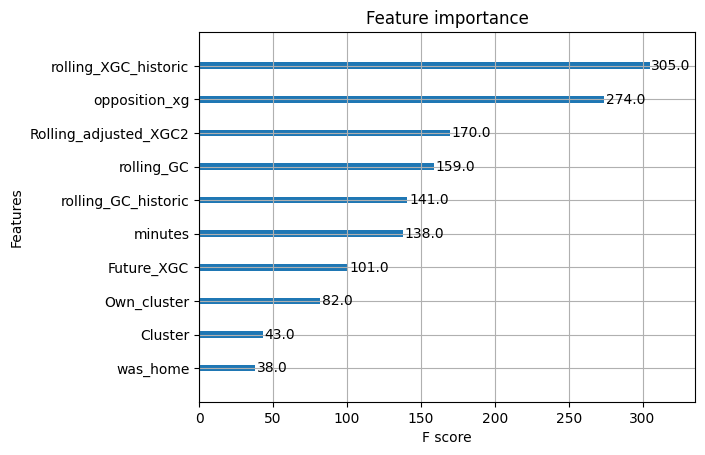

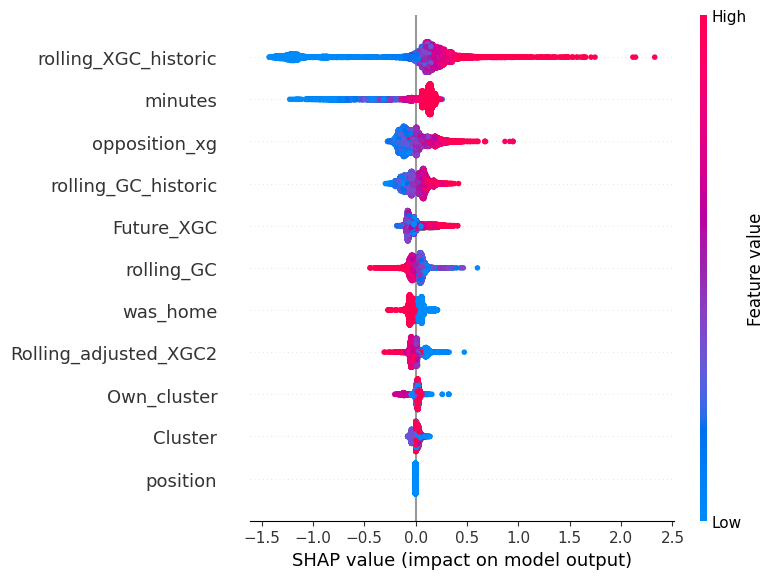

tensor(0.7178, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fábio_Ferreira Vieira
Gabriel_Fernando de Jesus
Gabriel_dos Santos Magalhães
Kai_Havertz0
Kai_Havertz1
Jurriën_Timber
Jorge_Luiz Frello Filho0
Jorge_Luiz Frello Filho1
Jakub_Kiwior
Gabriel_Martinelli Silva
Ethan_Nwaneri
Martin_Ødegaard
David_Raya Martin0
David_Raya Martin1
Declan_Rice0
Declan_Rice1
Bukayo_Saka
William_Saliba
Thomas_Partey


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Kieran_Tierney
Leandro_Trossard0
Leandro_Trossard1
Benjamin_White
Oleksandr_Zinchenko
Raheem_Sterling0
Raheem_Sterling1
Riccardo_Calafiori
Myles_Lewis-Skelly
Mikel_Merino
Leon_Bailey
Ross_Barkley0
Ross_Barkley1
Emiliano_Buendía Stati
Matty_Cash
Leander_Dendoncker0
Leander_Dendoncker1
Moussa_Diaby
Diego_Carlos Santos Silva
Lucas_Digne
Jhon_Durán
Boubacar_Kamara


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

bonus


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

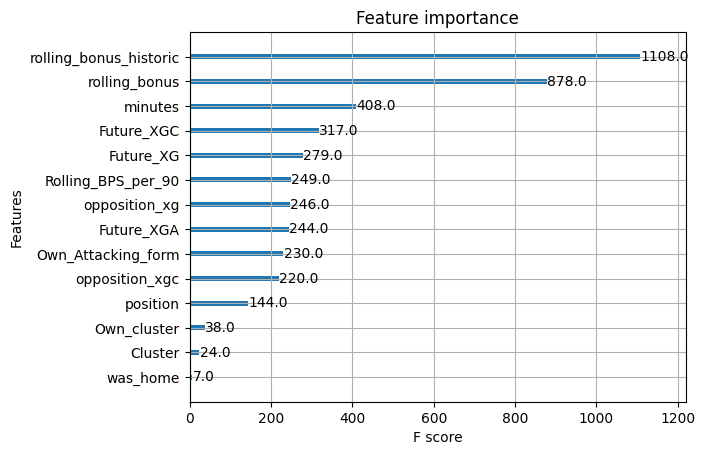

tensor(0.2993, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:440: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:441: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
[ 0.64731002  0.47455734  0.61759669 -0.01417458  0.49180466  0.71719444]


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:547: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:493: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:494: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
[ 0.23510402  0.21005796  0.22657263 -0.09062804  0.21207194  0.2870999 ]


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

total_points


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\2094934219.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

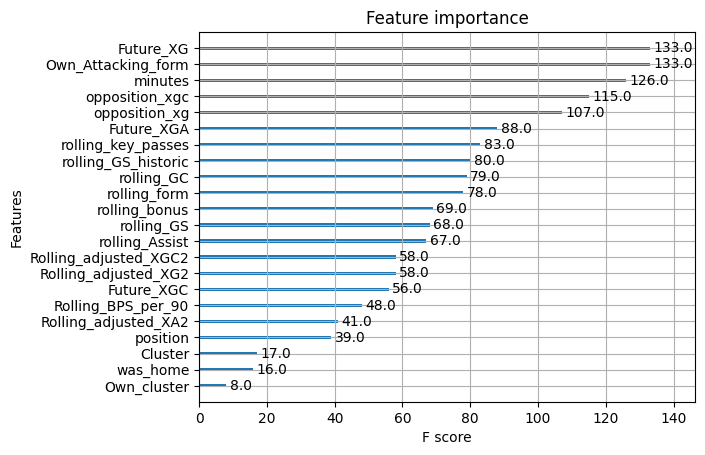

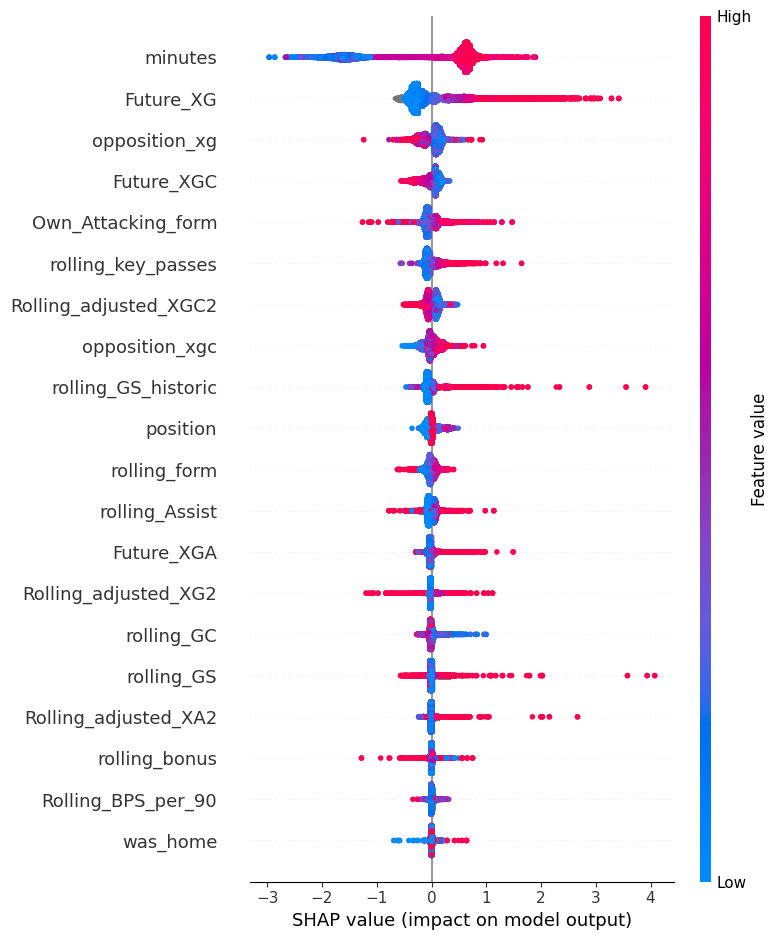

tensor(1.5988)


In [33]:

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder
import pytz
import torch.nn as nn
import torch
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

criterion = nn.L1Loss()
df=pd.read_csv("testML3.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        times=[]
        filtered = new_filtered[new_filtered["minutes"] > 0]
        for g in range(len(filtered)):
            times.append(max_t-g)
        times.reverse()
        filtered["time"]=times
        if(len(unique_teamvals)>1):
            filtered['name']=filtered['name'].values[0]+str(t)
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)

time_df.to_csv("ML_training2.csv")
def Stat_preds(is_pred, pred_variable,column_list,horizon):
    horizon=horizon
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    team_data=pd.read_csv("Team_prediction.csv").iloc[:,1:]
    max_time=data["time"].max()
    if(is_pred==0):
        max_time=max_time-horizon
    time_list=list(range(max_time, max_time-horizon, -1))
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    data['rolling_Threat'] = data['rolling_Threat'].fillna(10)
    data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)
    data['rolling_ICT'] = data['rolling_ICT'].fillna(5)
    
    pred_data=data[data['time'].isin(time_list)]
    players=data["name"].unique()
    all_preds=[]
    MSE=[]
    for i in range(len(players)):
        print(players[i])
        preds=[]
        val_preds=[]
        val_real=[]
        df=pred_data[pred_data["name"]==players[i]]
        team=df['Team'].values[-1]
        team_stats=team_data[team_data["team_code"]==team].sort_values(by='pred')
        if(len(team_stats)<1):
            continue
        df["team_XG"]=team_stats["XG"].values[:horizon]
        df["team_XGC"]=team_stats["XGC"].values[:horizon]
        df=df.sort_values(by='time')
        df2=data[data["name"]==players[i]]
        season_filter=df2[(df2['season'] == 25)]
        if(len(season_filter)<1):
            continue
        if(pred_variable=="GOALS"):
           df["pred"]=(df['Rolling_adjusted_XG2']*(df['team_XG'])*0.5+0.004*df['rolling_Threat'])*(1+df['XG_slope'])
           real_variable="expected_goals" 
        if(pred_variable=="Assist"):
           real_variable="expected_assists"  
           df["pred"]=(df['Rolling_adjusted_XA2']*(df['team_XG']) *0.6+0.035*df['rolling_key_passes'])*(1+df['XA_slope'])
            
        if(pred_variable=="GC"):
            real_variable="expected_goals_conceded"
            if(df["position"].values[0] in ["FWD","MID"]):
                continue
            team=df['Team'].values[-1]
            time_filter = data[(data['season'] == 25)]
            team_filter=time_filter[time_filter["Team"]==team]
            team_filter = team_filter.groupby('name')['minutes'].sum().reset_index()
            if(len(team_filter)<1):
                continue
            else:
                player_with_most_minutes = team_filter.loc[team_filter['minutes'].idxmax(), 'name']
                filtered_df=data[data["name"]==player_with_most_minutes]
                filtered_df = filtered_df[(filtered_df['season'] == 30)]

            df["pred"]=df["team_XGC"].values
            
        if(pred_variable=="bps"):
           real_variable="bonus" 
           df["pred"]=df['Rolling_adjusted_BPS2']*0.04
        
        if(pred_variable=="Fantasy"):
           real_variable="total_points"  
           df["pred"]=df['Rolling_adjusted_Fantasy2']*(df['team_XG'])
            
        preds.append(df["name"].values[0])
        df["pred"]=df["pred"].round(2)
        #if(df['pred'].isna().any()):
            #continue
        for r in range(len(df.values)):
            preds.append(df["pred"].values[r])
            val_preds.append(df["pred"].values[r])
            val_real.append(df[real_variable].values[r])
            
        preds.append(df["position"].values[0])
        all_preds.append(preds)
        #MSE.append(mean_squared_error(val_real, val_preds))
        
    columns=column_list
    data_f=pd.DataFrame(all_preds, columns=columns)
    data_f.to_csv(f"STAT_{pred_variable}_preds2.csv", index=False)
    #print(sum(MSE) / len(MSE))
def XGB_Make_dataset(position,position2):
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    #df=df[df['position'] == position2]
    if(position in['Assist','GOALS']):
        df = df.dropna(subset=['XG_Mean_difference', 'XA_Mean_difference'])
    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)

    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc

    trainingdf=df[["Threat_slope","XA_slope","XG_slope","minutes","season","opposition_xg","Average_Overscore","opposition_xgc", "rolling_form","rolling_XG","Team","name","position","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos","rolling_ICT","Overscore","XGC_DEF","XGC_FWD","XGC_MID"
                   ,"Rolling_adjusted_XG2","Rolling_adjusted_XGC2","Rolling_adjusted_XA2","rolling_GS_historic","rolling_XG_historic","goals_scored","expected_goals"
                  ,"assists","rolling_Assist_historic","rolling_Assist","rolling_XA_historic","expected_assists","rolling_GC_historic","rolling_XGC_historic","clean_sheets",
                   "expected_goals_conceded", "rolling_bps","rolling_bps_historic","rolling_bonus_historic","rolling_bonus","bonus","rolling_key_passes","rolling_shots","Own_Attacking_form","Rolling_BPS_per_90"
                  ,"XG_Mean_difference","XA_Mean_difference","Shot_Mean_difference","Adjusted_XG_Mean_difference","Threat_Mean_difference","rolling_Threat","XG_Mean"]]
    
    
    names= df['name'].unique()
    time_df=pd.DataFrame()
    for i in range(len(names)):
        times=[]
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name].copy()
        filtered['rolling_XG'] = filtered['rolling_XG'].shift(1)
        filtered['rolling_GC'] = filtered['rolling_GC'].shift(1)
        filtered['rolling_XA'] = filtered['rolling_XA'].shift(1)
        filtered['rolling_GS_historic'] = filtered['rolling_GS_historic'].shift(1)
        filtered['rolling_XG_historic'] = filtered['rolling_XG_historic'].shift(1)
        filtered['rolling_XA_historic'] = filtered['rolling_XA_historic'].shift(1)
        filtered['rolling_Assist'] = filtered['rolling_Assist'].shift(1)
        filtered['rolling_Assist_historic'] = filtered['rolling_Assist_historic'].shift(1)
        filtered['rolling_bps'] = filtered['rolling_bps'].shift(1)
        #filtered['Rolling_adjusted_XGC'] = filtered['Rolling_adjusted_XGC'].shift(1)
        #filtered['Rolling_adjusted_XG'] = filtered['Rolling_adjusted_XG'].shift(1)
        filtered['Overscore'] = filtered['Overscore'].shift(1)
        filtered['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
        filtered['Future_XG'] = filtered['Rolling_adjusted_XG2']*filtered['opposition_xgc']
        filtered['Future_XG2'] = filtered['Rolling_adjusted_XG2']*(filtered['opposition_xgc']*0.8+0.1*filtered['Own_Attacking_form']**2)
        
        filtered['Future_XGC'] = filtered['Rolling_adjusted_XGC2']*filtered['opposition_xg']
        filtered['Future_XGA'] = filtered['Rolling_adjusted_XA2']*filtered['opposition_xgc']
        filtered['XG_diff'] = filtered["rolling_XG"]-filtered['rolling_XG_historic']
        filtered['XA_diff'] = filtered["rolling_XA"]-filtered['rolling_XA_historic']
        filtered['opposition_xgc_bucket'] = pd.cut(filtered['opposition_xgc'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        filtered['opposition_xg_bucket'] = pd.cut(filtered['opposition_xg'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)

        filtered['Own_Attacking_form_bucket'] = pd.cut(filtered['Own_Attacking_form'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        # Convert to numeric (this removes the categorical dtype)
   
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
    trainingdf=time_df
    trainingdf['Team'] = trainingdf['Team'].astype('category')
    trainingdf['name'] = trainingdf['name'].astype('category')
    trainingdf['opposition_xgc_bucket'] = trainingdf['opposition_xgc_bucket'].astype(float)
    trainingdf['Own_Attacking_form_bucket'] = trainingdf['Own_Attacking_form_bucket'].astype(float)
    trainingdf['opposition_xg_bucket'] = trainingdf['opposition_xg_bucket'].astype(float)
    trainingdf['position'] = trainingdf['position'].astype('category')
    trainingdf['gamepos'] = trainingdf['gamepos'].astype('category')
    trainingdf['Shot_Mean_difference'] = trainingdf['Shot_Mean_difference'].fillna(0)
    trainingdf['Threat_Mean_difference'] = trainingdf['Threat_Mean_difference'].fillna(0)
    trainingdf['Adjusted_XG_Mean_difference'] = trainingdf['Adjusted_XG_Mean_difference'].fillna(0)
    trainingdf['XG_Mean_difference'] = trainingdf['XG_Mean_difference'].clip(lower=-1, upper=2)
    trainingdf['XA_Mean_difference'] = trainingdf['XA_Mean_difference'].clip(lower=-1, upper=3)
    trainingdf.replace([np.inf, -np.inf], 1, inplace=True)
    if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["position","XG_diff","opposition_xgc","Own_Attacking_form","Team","name","Cluster"
                   ,"time","minutes","Shot_Mean_difference","XG_slope","season","XG_Mean_difference","Threat_slope"]]
        target_value="XG_Mean_difference"
        
    elif(position=='Assist'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["XA_diff","position","opposition_xgc","Own_Attacking_form","Rolling_adjusted_XA2","Team","name","Own_cluster","Cluster"
                   ,"time","minutes","rolling_XA_historic","XA_Mean_difference","season","rolling_key_passes","XA_slope"]]
        target_value="XA_Mean_difference"
        
    elif(position=='GC'):
        trainingdf=trainingdf[trainingdf['position'] == "DEF"]
        trainingdf=trainingdf[["position","opposition_xg","Rolling_adjusted_XGC2","Team","name","Own_cluster","Cluster"
                   ,"was_home","rolling_GC","time","minutes","Future_XGC","rolling_GC_historic","rolling_XGC_historic","expected_goals_conceded","season"]]
        target_value="expected_goals_conceded"
        
    elif(position=='bps'):
        trainingdf=trainingdf[["opposition_xgc","position","opposition_xg","Own_Attacking_form","rolling_bonus_historic","rolling_bonus","bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_BPS_per_90"]]
        target_value="bonus"
        
    elif(position=='Fantasy'):
        trainingdf=trainingdf[["total_points","opposition_xg","opposition_xgc","position","Own_Attacking_form","rolling_bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_adjusted_XA2","rolling_key_passes","rolling_Assist","Rolling_adjusted_XG2"
                    ,"rolling_GS","rolling_GS_historic","Rolling_adjusted_XGC2","rolling_GC","rolling_form","Rolling_BPS_per_90"]]
        target_value="total_points"
        
    elif(position=='GK'):
        trainingdf=trainingdf[["opposition_xg","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GC","time","gamepos"]]
        
    elif(position=='GOALS2'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_goals","opposition_xgc","Own_Attacking_form",
                               "Team","name","time","minutes","season","rolling_Threat","position","rolling_XG_historic","Cluster","Rolling_adjusted_XG2"]]
        target_value="expected_goals"   

    else:
        trainingdf=trainingdf[["opposition_xg","opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos",'Future_XG',"Future_XGA"]]
    trainingdf.to_csv("xgb_test_data.csv")
    print(target_value)
    return trainingdf,target_value
    
def XGB_Train(rounds, eta,max_depth,gamma,min_c,dtrain,target_value,train,Y_train  ):
    if(target_value=='bonus'):
        params = {
            'objective': 'multi:softprob',
            'max_depth': max_depth,
            'eta': eta,
            'eval_metric': 'mlogloss',
            'tree_method': 'hist',
            'grow_policy': 'lossguide',
            'lambda': 2,
            'gamma': gamma,
            'min_child_weight': min_c,
            'num_class': 4
        }

        # Train using xgboost.train
        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model

    else:
        params = {
            'max_depth': max_depth,
            'eta': eta,
            'objective': 'reg:squarederror',  # Use 'reg:squarederror' for regression
            'eval_metric': 'rmse',             # Use 'rmse' (root mean squared error) for evaluation
            'tree_method':'hist',
            'grow_policy': 'lossguide',
            'lambda': 2, 
            'gamma':gamma,
            'min_child_weight': min_c
        }

        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model


def XGB_Make_Pred(trainingdf,target_value,position2,column_list,predlength):
    X_train=pd.DataFrame()
    names= trainingdf['name'].unique()


    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - predlength*2

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    full=['Mohamed_Salah','Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)

    full=['Mohamed_Salah']
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r2'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)
    
    X_test=pd.DataFrame()

    max_cutoff=predlength
    min_cutoff=0
    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - max_cutoff
        training_cutoff2 = filtered["time"].max() - min_cutoff
        name_df=filtered[lambda x: x.time > training_cutoff]
        name_df=name_df[lambda x: x.time <= training_cutoff2]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

    total=[]
    
    Y_train=X_train[[target_value]]
    Y_test=X_test[[target_value]]

    train = X_train.drop(columns=[target_value,'time',"name","Team","season"])
    test = X_test.drop(columns=['time'])

    dtrain = xgb.DMatrix(train, label=Y_train,enable_categorical=True)

    dtest = xgb.DMatrix(test, label=Y_test,enable_categorical=True)



    preds_list=test['name'].unique()
    test.to_csv("Debugg.csv")
    model=XGB_Train(60,0.1,5,0.1,6,dtrain,target_value,train,Y_train )
    row2=[]
    actuals=[]
    df2=pd.read_csv("ML_training2.csv").iloc[:,1:]
    for i in range(len(preds_list)):
        row=[]
        player=[]
        player.append(preds_list[i])
        row.append(preds_list[i])
        filtered_df = test[test['name'].isin(player)]
        min_cutoff=max(min_cutoff,1)
        xg_mean=df2[df2['name'].isin(player)]["XG_Mean"]
        xa_mean=df2[df2['name'].isin(player)]["XA_Mean"]
        xg=df2[df2['name'].isin(player)]["expected_goals"]
        xa=df2[df2['name'].isin(player)]["expected_assists"]
        if(target_value=="expected_goals_conceded"):
            team=filtered_df['Team'].values[-1]
            
            team_filter=trainingdf[trainingdf["Team"]==team]
            time_filter = team_filter[team_filter['season'] == 25]
            if(len(time_filter)<1):
                continue
            else:
                player_with_most_minutes = time_filter.loc[time_filter['minutes'].idxmax(), 'name']
                print(player_with_most_minutes)
                filtered_df=test[test["name"]==player_with_most_minutes]
        filtered.drop(columns=['time'])
        y=filtered_df[[target_value]]
        filtered_df = filtered_df.drop(columns=[target_value,'name',"Team","season"])
        dtest = xgb.DMatrix(filtered_df, label=y,enable_categorical=True)
        y_pred = model.predict(dtest)
        for g in range(len(y_pred)):
            
            if(target_value=="XG_Mean_difference"):
                row.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="XA_Mean_difference"):
                row.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="bonus"):
                row.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)
                row2.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)      
            else:
                row.append(y_pred[g])
                row2.append(y_pred[g])
        for t in range(len(y_pred)):
            if(target_value=="XG_Mean_difference"):
                row.append(xg.values[-(max_cutoff-t)])
                actuals.append(xg.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])
            elif(target_value=="XA_Mean_difference"):
                row.append(xa.values[-(max_cutoff-t)])
                actuals.append(xa.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])

            else:
                row.append(y.values[t][0])
                actuals.append(y.values[t][0])

        row.append(filtered_df["position"].values[0])
        total.append(row)
    from xgboost import plot_importance
    import matplotlib.pyplot as plt
    import shap

    le = LabelEncoder()
    train['position'] = le.fit_transform(train['position'])
    # Plot feature importance
    plot_importance(model, importance_type='weight')
    plt.show()
    if(target_value!="bonus"):
        explainer = shap.Explainer(model)

        # Compute SHAP values
        shap_values = explainer(train)  # X is your feature matrix
        shap.summary_plot(shap_values, train)
    
    print(criterion(torch.tensor(row2), torch.tensor(actuals)))
    column_list = []
    column_list.append("Name")
    for s in range(predlength):
        column_list.append(f"p{s+1}")
    for e in range(predlength):
        column_list.append(f"y{e+1}")
    column_list.append("position")
    columns=column_list
    data_f=pd.DataFrame(total, columns=columns)
    return data_f
    
def XGB(position,position2,column_list,predlength):
    data,target_value=XGB_Make_dataset(position,position2)
    pred=XGB_Make_Pred(data,target_value,position2,column_list,predlength)
    return pred
def Generate_LSTM_preds(pred,column_list,predlength):
    if(pred in ["GC","Fantasy"]):
        return 0
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    unique_players=data["name"].unique()
    pred_all_players=pd.DataFrame(columns=column_list)
    window=8
    future=predlength
    for k in range(len(unique_players)):
        pred_player_df=[]
        player_name=unique_players[k]
        
        pred_player_df.append(player_name)
        
        df=data[data["name"]==unique_players[k]]
        position=df["position"].values[-1]
        past_df=df[df["season"]!=30].sort_values(by="time", ascending=True)

        test_df=df[df["season"]==25]
        if(len(test_df)<1):
            continue
        
        if(pred=="GOALS"):
            past_columns=["minutes","shots","Threat","expected_goals"]
            past_columns=["minutes","rolling_XG_historic","Threat","expected_goals"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_goals"
            model_path="LSTM_Goals2.h5"
        elif(pred=="Assist"):
            past_columns=["minutes","key_passes","creativity","expected_assists"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_assists"
            model_path="LSTM_Assist2.h5"
        elif(pred=="bps"):
            past_columns=["minutes","ICT","total_points","bonus"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="bonus"
            model_path="LSTM_Bonus.h5"



        past_df=past_df[past_columns]

        past_scaler = MinMaxScaler(feature_range=(0, 1))
        past_scaler.fit(data[past_columns].to_numpy())
        past_df[past_columns]=past_scaler.transform(past_df[past_columns].to_numpy())

        
        if len(past_df) < window:
            num_missing = window - len(past_df)
            zero_rows = pd.DataFrame(np.zeros((num_missing, past_df.shape[1])), columns=past_df.columns)
            past_df = pd.concat([zero_rows, past_df], ignore_index=True)

        opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
        opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
        df["opposition_xg"]=opp_xg
        df["opposition_xgc"]=opp_xgc

        future_scaler = MinMaxScaler(feature_range=(0, 1))
        
        future_scaler.fit(data[future_columns].to_numpy())
        df[future_columns]=future_scaler.transform(df[future_columns].to_numpy())
    
        

        future_data=df[df["season"]==30].sort_values(by="time", ascending=True)
        future_data=future_data[future_columns]
        
        if len(future_data) < future:
            num_missing = future - len(future_data)
            zero_rows = pd.DataFrame(np.zeros((num_missing, future_data.shape[1])), columns=future_data.columns)
            future_data = pd.concat([zero_rows, future_data], ignore_index=True)

        
        future=len(future_data)

        past_df=past_df.iloc[-window:,:]

        X_test=[]
        X_future=[]
        for i in range(future): 
            X_test.append(past_df.values)
            X_future.append([future_data.values[i]])

        X_test = np.array(X_test)
        X_future = np.array(X_future)

        if(player_name=="Mohamed_Salah"):
            print(X_test)
            print(X_future)
        # Load the model
        model = load_model(model_path, compile=False)

        # Compile again with the correct loss function
        model.compile(optimizer='adam', loss=MeanSquaredError()) 


        predictions = model.predict([X_test, X_future])

        y_pred_rescaled = past_scaler.inverse_transform(
            np.concatenate((np.zeros((len(predictions), len(past_columns) - 1)), predictions.reshape(-1, 1)), axis=1)
        )[:, -1]
        print(y_pred_rescaled)
        for y in range(len(y_pred_rescaled)):
            pred_player_df.append(y_pred_rescaled[y])
        pred_player_df.append(position)
        append_df=pd.DataFrame([pred_player_df], columns=column_list)
        pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)

    pred_all_players.to_csv(f"LSTM_{pred}.csv") 
def Make_Predictions ():
    predlength=6
    is_pred=1
    column_list = []
    column_list.append("Name")
    for k in range(predlength):
        column_list.append(f"p{k+1}")
    column_list.append("position")
    positions=["GOALS", "Assist","GC","bps","Fantasy"]
    for y in range(len(positions)):
        XGB_pred=pd.DataFrame()
        position_filter=positions[y]
        Stat_preds(is_pred, position_filter,column_list,predlength)

        pred2=XGB(position_filter,"FWD",column_list,predlength)
        XGB_pred=pd.concat([XGB_pred, pred2], axis=0, ignore_index=True)
            
        XGB_pred.to_csv(f"XGB_{position_filter}_preds2.csv", index=False)
        Generate_LSTM_preds(position_filter,column_list,predlength)

if __name__ == '__main__':
    Make_Predictions()
#0.0306
#0.0924

In [3]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data=pd.read_csv("ML_training2.csv").iloc[:,1:]
opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
data["opposition_xg"]=opp_xg
data["opposition_xgc"]=opp_xgc
data["FXG"]=data['Rolling_adjusted_XG2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2)
data["FXA"]=data['Rolling_adjusted_XA2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2) 
data["Fbs"]=data['Rolling_adjusted_BPS']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data["Fpoints"]=data['Rolling_adjusted_Fantasy2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data=data[data["season"]!= 30]

full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood1','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen','Jean-Philippe_Mateta','Kevin_De Bruyne','Morgan_Gibbs-White1','Bernardo_Veiga de Carvalho e Silva','Anthony_Gordon1'
         'Jarrod_Bowen','Lucas_Digne','Son_Heung-min','Dwight_McNeil','Ezri_Konsa Ngoyo','Alex_Iwobi1','Raúl_Jiménez1','Jamie_Vardy','Issa_Diop1','Emile_Smith Rowe1','Yoane_Wissa','Rico_Lewis','Diogo_Dalot Teixeira','Alejandro_Garnacho','Marc_Guéhi',
        'Joël_Veltman','Virgil_van Dijk','Dejan_Kulusevski','Cole_Palmer1','Marcus_Tavernier','Luis_Díaz','Ethan_Pinnock','Marcos_Senesi','Facundo_Buonanotte1','Matheus_Santos Carneiro Da Cunha','Noni_Madueke','Mohammed_Kudus','Murillo_Santiago Costa dos Santos',
         'Daniel_Muñoz','Morgan_Rogers','Mitoma_Kaoru','Ola_Aina','Dominic_Solanke-Mitchell','Jørgen_Strand Larsen','Liam_Delap','Maxence_Lacroix']
data=data[data['name'].isin(full)]



data['FXG'] = data['FXG'].fillna(0)
data['Fbs'] = data['Fbs'].fillna(0)
data['FXA'] = data['FXA'].fillna(0)
data['rolling_Threat'] = data['rolling_Threat'].fillna(5)
data['rolling_ICT'] = data['rolling_ICT'].fillna(3)
data['Fpoints'] = data['Fpoints'].fillna(3)
data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)

"""data_to_scale=data[["rolling_key_passes","rolling_ICT"]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
data["PC1"]=pca_df["PC1"].values
data["PC2"]=pca_df["PC2"].values"""


X_train=data[["Fpoints","rolling_ICT","minutes"]]
y_train=data["total_points"]
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
feature_names = X_train.columns
coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {intercept:.4f}')
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const).fit()

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())
#R 0.183
#AIC -1.35

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23480\2054453387.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23480\2054453387.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fpoints: 0.2504
rolling_ICT: 0.2015
minutes: 0.0313
Intercept: -0.3975
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     305.5
Date:                Fri, 04 Apr 2025   Prob (F-statistic):          1.29e-182
Time:                        10:41:26   Log-Likelihood:                -13938.
No. Observations:                5179   AIC:                         2.788e+04
Df Residuals:                    5175   BIC:                         2.791e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [36]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
double=[[31,43,7,3],[0],[0],[43,7,91,6],[0],[0]]
blank=[[0],[31,43,7,3],[0],[0],[43,7,91,6],[0]]
double_round=[0]
horizon=6
def forwards():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="FWD"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["name"]==player_name]
        player_data=player_data[player_data["position"]=="FWD"]
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        
        Point_prediction.append(player_name)
        team=player_data["Team"].values[0]
        for u in range(horizon):
            overscore=max(0.85,player_data["Average_Overscore"].values[-((8-u))])
            overscore=min(1.25,overscore)
            overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
            overassist=min(1.8,overassist)
            fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
            print(LSTM_goal_preds.values[0][u+1])
            goal_point=(TFT_goal_preds.values[0][u+1]*0.5+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.3)*overscore

                        
            assist_point=(TFT_assist_preds.values[0][u+1]*0.5+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.3)*overassist
            
            bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)*0.8    
            
            points=(2+goal_point*4+assist_point*3+bonus)*0.7+0.3*fantasy
            Point_prediction.append(points)
            Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(points)
            aactuals.append(player_data["total_points"].values[-((5-u)+5)])
    
        n = horizon  # Length of prediction array
        
        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("FWD")
            
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
    
    
    return 1

def mid():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="MID"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="MID"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.85,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.25,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(1.8,overassist)
            
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0.0+min(XGB_point_preds.values[0][u+1],8)*1
            
                goal_point=(TFT_goal_preds.values[0][u+1]*0.5+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.3)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.5+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.3)*overassist

                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)*0.8        
                
                points=(2+goal_point*5+assist_point*3+bonus)*0.7+0.3*fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        
            
        Point_prediction.append("MID")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f


def defenders():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="DEF"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    XGB_GC=pd.read_csv((f"XGB_{"GC"}_preds2.csv"))
    XGB_GC = XGB_GC[XGB_GC['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"Assist"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="DEF"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_GC_preds=XGB_GC[XGB_GC["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.5,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(2,overassist)
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
                
                goal_point=(TFT_goal_preds.values[0][u+1]*0.5+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.3)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.5+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.3)*overassist
            
                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)*0.8   
            
                GC=TFT_GC_preds.values[0][u+1]*1+XGB_GC_preds.values[0][u+1]*0
            
                points=(goal_point*6+assist_point*3+bonus+2.5/GC)*0.75+0.25*fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("DEF")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
                           
def gk():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="GKP"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    players=TFT_points["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        print(player_name)
        player_data=players_data[players_data["position"]=="GKP"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                fantasy=(2.5/TFT_GC_preds.values[0][u+1])*0.7+0.3*XGB_point_preds.values[0][u+1]
                points=fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        n = horizon  # Length of prediction array


        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("GK")
        
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f

def main():
    total_preds=pd.DataFrame()
    positions=["FWD", "DEF","MID","GKP"]
    for i in range(len(positions)):
        pos=positions[i]
        if(pos=="FWD"):
            preds=forwards()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        elif(pos=="MID"):
            preds=mid()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
            
        elif(pos=="GKP"):
            preds=gk()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)

        else:
            preds=defenders()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
    
    total_preds.to_csv("All_Predictions.csv")
    
if __name__ == '__main__':
    main()

Gabriel_Fernando de Jesus
0.3784877157211303
0.292557980120182
0.3803479109704494
0.0887478486448526
0.2954048214107752
['Gabriel_Fernando de Jesus', 8.382085494464588, 0, 4.271700448206902, 3.398144295936632, 4.039076457182849, 4.392521883486595, 'FWD']
[16, 2, 12, 2, 1, 2]
Kai_Havertz0
0.5326435700058937
0.4664023420214652
0.5411626508831977
0.1674934174865484
0.4692492452263831
['Kai_Havertz0', 10.697987489623724, 0, 5.837175619341389, 4.1050585649713405, 5.464837991493021, 5.493317182403194, 'FWD']
[1, 7, 2, 12, 1, 2]
Jhon_Durán
0.2137418702244758
0.149967288300395
0.2171842654049396
0.1856154101341962
0.2255443709343671
['Jhon_Durán', 6.76632002973684, 0, 3.757799674384689, 7.290032091107222, 0, 3.755066448934948, 'FWD']
[7, -2, 1, 1, 1, 2]
Ollie_Watkins
0.1712835338339209
0.1219640996307134
0.1785077901184558
0.1436368891224265
0.2031252352148294
['Ollie_Watkins', 7.492989293084855, 0, 4.338353767732959, 8.544170931453849, 0, 4.172366895831698, 'FWD']
[9, 0, 2, 7, 1, 2]
Enes_Ünal

In [37]:
import pandas as pd
df=pd.read_csv("All_Predictions.csv").iloc[:,1:]
print(df)
Last_GW=32
# Melt the DataFrame to long format for 'p' and 't'
df_p = df.melt(id_vars=['Name', 'position'], value_vars=['p1', 'p2', 'p3','p4','p5','p6'], var_name='p_index', value_name='Predictions')

# Add time index based on the column name ('p1', 'p2', 'p3' -> 1, 2, 3)
df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
 



# Drop the index columns used for melting
df_p = df_p[['Name', 'Predictions','position', 'time_index']]

# Sort and reset index if needed
df_p = df_p.sort_values(by=['Name', 'time_index']).reset_index(drop=True)
print(1)
# Print the transformed DataFrame
df_p.to_csv("Model_Predictions.csv")

                          Name         p1        p2        p3        p4  \
0    Gabriel_Fernando de Jesus   8.382085  0.000000  4.271700  3.398144   
1                 Kai_Havertz0  10.697987  0.000000  5.837176  4.105059   
2                   Jhon_Durán   6.766320  0.000000  3.757800  7.290032   
3                Ollie_Watkins   7.492989  0.000000  4.338354  8.544171   
4                    Enes_Ünal   3.102071  3.444183  2.778096  6.518487   
..                         ...        ...       ...       ...       ...   
476           Łukasz_Fabiański   2.007921  1.942358  1.920949  2.098385   
477             Sam_Johnstone0   2.326453  2.189016  1.955251  2.263057   
478        José_Malheiro de Sá   2.270498  2.146988  1.958567  2.235075   
479             Antonín_Kinsky   2.182903  1.822848  2.357196  4.225943   
480                Alex_Palmer   1.764586  1.439629  2.122849  1.907488   

           p5        p6 position  
0    4.039076  4.392522      FWD  
1    5.464838  5.493317      

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_25804\922381830.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)


Marc_Cucurella Saseta
Aaron_Wan-Bissaka0
Levi_Colwill0
